# CSL7110 Assignment 3: Recommender Systems — M25DE1077 (Sourin Ghosh)

## Setup & Dependencies

In [1]:
!pip install scikit-learn scipy pandas numpy scikit-surprise shap lime tensorflow

import warnings, os, time, gc
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
from IPython.display import display
import pandas as pd
import scipy.sparse as sp
from scipy.sparse.linalg import svds
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
from sklearn.preprocessing import normalize
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 100

DATA_DIR = "./ml-latest"
assert os.path.isdir(DATA_DIR), f"Dataset not found: {DATA_DIR}"
print("Imports OK")



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Imports OK


## Data Loading

In [2]:
def load_movies(data_dir=DATA_DIR):
    df = pd.read_csv(os.path.join(data_dir, "movies.csv"))
    df['year']       = df['title'].str.extract(r'\((\d{4})\)').astype(float)
    df['genres_str'] = df['genres'].str.replace('|', ' ', regex=False)
    df['genres_list']= df['genres'].str.split('|')
    print(f"  Movies: {len(df):,}")
    return df

def load_ratings(data_dir=DATA_DIR, chunksize=500_000, sample_frac=0.1):
    """Chunk-reads ratings for large files"""
    path = os.path.join(data_dir, "ratings.csv")
    chunks = []
    for chunk in pd.read_csv(path, chunksize=chunksize,
                              dtype={'userId':'int32','movieId':'int32','rating':'float32'}):
        if sample_frac and sample_frac < 1.0:
            chunk = chunk.sample(frac=sample_frac, random_state=42)
        chunks.append(chunk)
    df = pd.concat(chunks, ignore_index=True)
    print(f"  Ratings: {len(df):,} | Users: {df.userId.nunique():,} | Items: {df.movieId.nunique():,}")
    return df

print("Loading data …")
movies  = load_movies()
ratings = load_ratings()

# Train/test split
train_r, test_r = train_test_split(ratings, test_size=0.2, random_state=42)
sample_user = int(ratings['userId'].value_counts().index[0])
print(f"  Train: {len(train_r):,}  Test: {len(test_r):,}  Sample user: {sample_user}")


Loading data …
  Movies: 9,742
  Ratings: 10,084 | Users: 603 | Items: 3,653
  Train: 8,067  Test: 2,017  Sample user: 414


In [3]:
def build_sparse_matrix(df):

    u_cat  = df['userId'].astype('category')
    i_cat  = df['movieId'].astype('category')
    mat    = sp.csr_matrix(
        (df['rating'].values.astype(np.float32),
         (u_cat.cat.codes.values.astype(np.int32),
          i_cat.cat.codes.values.astype(np.int32))),
        shape=(len(u_cat.cat.categories), len(i_cat.cat.categories)))
    uid_map  = dict(zip(u_cat.cat.categories, range(len(u_cat.cat.categories))))
    iid_map  = dict(zip(i_cat.cat.categories, range(len(i_cat.cat.categories))))
    uid_rmap = {v:k for k,v in uid_map.items()}
    iid_rmap = {v:k for k,v in iid_map.items()}
    return mat, uid_map, iid_map, uid_rmap, iid_rmap

print("Building sparse matrix …")
mat, uid_map, iid_map, uid_rmap, iid_rmap = build_sparse_matrix(train_r)
density = mat.nnz / (mat.shape[0]*mat.shape[1]+1e-9)
print(f"  Shape: {mat.shape} | Density: {density:.4%} | NNZ: {mat.nnz:,}")


Building sparse matrix …
  Shape: (592, 3249) | Density: 0.4194% | NNZ: 8,067


---
## Part 1: Content-Based Filtering
### Task 1: TF-IDF Item-to-Item Recommendation

In [4]:
class TFIDFRecommender:

    def __init__(self, movies_df):
        self.movies = movies_df.reset_index(drop=True)
        tfidf = TfidfVectorizer(token_pattern=r'[^\s]+', max_features=500)
        self.tfidf_matrix = tfidf.fit_transform(
            self.movies['genres_str'].fillna(''))
        self.vectorizer = tfidf
        self.title_idx = pd.Series(self.movies.index,
                                   index=self.movies['title'].str.lower())
        print(f"  TF-IDF shape: {self.tfidf_matrix.shape}")

    def recommend(self, title, n=5):
        key = title.lower()
        if key not in self.title_idx:
            key = next((t for t in self.title_idx.index if key in t), None)
            if key is None: raise ValueError(f"'{title}' not found")
        idx  = self.title_idx[key]
        sims = linear_kernel(self.tfidf_matrix[idx], self.tfidf_matrix).flatten()
        sims[idx] = -1
        top = np.argsort(sims)[::-1][:n]
        res = self.movies.iloc[top][['title','genres']].copy()
        res['cosine_similarity'] = sims[top].round(4)
        return res.reset_index(drop=True)

print("Building TF-IDF Recommender …")
tfidf_rec = TFIDFRecommender(movies)

for q in ['Toy Story (1995)', 'Inception (2010)', 'The Dark Knight (2008)']:
    try:
        print(f"\n── Top-5 for: {q}")
        display(tfidf_rec.recommend(q))
    except ValueError as e:
        print(e)


Building TF-IDF Recommender …
  TF-IDF shape: (9742, 22)

── Top-5 for: Toy Story (1995)


,title,genres,cosine_similarity
0,Turbo (2013),Adventure|Animation|Children|Comedy|Fantasy,1.0
1,Asterix and the Vikings (Astérix et les Viking...,Adventure|Animation|Children|Comedy|Fantasy,1.0
2,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,1.0
3,The Good Dinosaur (2015),Adventure|Animation|Children|Comedy|Fantasy,1.0
4,"Wild, The (2006)",Adventure|Animation|Children|Comedy|Fantasy,1.0



── Top-5 for: Inception (2010)


,title,genres,cosine_similarity
0,Watchmen (2009),Action|Drama|Mystery|Sci-Fi|Thriller|IMAX,0.9371
1,Super 8 (2011),Mystery|Sci-Fi|Thriller|IMAX,0.8637
2,RoboCop (2014),Action|Crime|Sci-Fi|IMAX,0.8267
3,"Fast Five (Fast and the Furious 5, The) (2011)",Action|Crime|Drama|Thriller|IMAX,0.8217
4,Strange Days (1995),Action|Crime|Drama|Mystery|Sci-Fi|Thriller,0.8168



── Top-5 for: The Dark Knight (2008)
'The Dark Knight (2008)' not found


### Task 2: User-Profile Content Recommender

In [5]:
class UserProfileRecommender:
    """
    Recommendation = cosine(profile, movie_vec)
    """
    def __init__(self, movies_df, ratings_df, tfidf_mat):
        self.movies  = movies_df.reset_index(drop=True)
        self.tfidf   = tfidf_mat
        self.mid2idx = pd.Series(self.movies.index, index=self.movies['movieId'])
        self._build_profiles(ratings_df)

    def _build_profiles(self, ratings_df):
        valid = ratings_df[ratings_df['movieId'].isin(self.mid2idx.index)].copy()
        valid['row'] = valid['movieId'].map(self.mid2idx)
        profiles = {}
        for uid, g in valid.groupby('userId'):
            w = g['rating'].values.astype(float)
            v = self.tfidf[g['row'].values]
            profiles[uid] = np.asarray(v.multiply(w[:,None]).sum(0)).flatten() / (w.sum()+1e-9)
        self.uids    = list(profiles.keys())
        self.P       = np.vstack(list(profiles.values()))   # U × V
        self.u2idx   = {u:i for i,u in enumerate(self.uids)}
        self.norm_tf = normalize(self.tfidf, norm='l2')
        print(f"  Profiles: {self.P.shape}")

    def recommend(self, uid, n=10, exclude_rated=True):
        if uid not in self.u2idx: raise ValueError(f"User {uid} unknown")
        pv   = self.P[self.u2idx[uid]]
        pv_n = pv / (np.linalg.norm(pv)+1e-9)
        sims = self.norm_tf.dot(pv_n)
        if exclude_rated:
            pass
        top  = np.argsort(sims)[::-1][:n]
        res  = self.movies.iloc[top][['movieId','title','genres']].copy()
        res['similarity'] = sims[top].round(4)
        return res.reset_index(drop=True)

    def evaluate(self, test_df, K=10, threshold=4.0, n_users=50):
        prec, rec = [], []
        for uid in list(test_df['userId'].unique())[:n_users]:
            if uid not in self.u2idx: continue
            gt = set(test_df[(test_df['userId']==uid)&(test_df['rating']>=threshold)]['movieId'])
            if not gt: continue
            try:
                recs = self.recommend(uid, n=K)
                hits = set(recs['movieId']) & gt
                prec.append(len(hits)/K); rec.append(len(hits)/len(gt))
            except: pass
        p,r = (np.mean(prec) if prec else 0), (np.mean(rec) if rec else 0)
        print(f"  CBF  Precision@{K}: {p:.4f}  Recall@{K}: {r:.4f}  (n={len(prec)})")
        return p, r

print("Building User-Profile Recommender …")
up_rec = UserProfileRecommender(movies, train_r, tfidf_rec.tfidf_matrix)
print(f"\nTop-10 for user {sample_user}:")
display(up_rec.recommend(sample_user))
print("\nEvaluating CBF …")
cbf_p, cbf_r = up_rec.evaluate(test_r, K=10, n_users=100)


Building User-Profile Recommender …
  Profiles: (592, 22)

Top-10 for user 414:


,movieId,title,genres,similarity
0,4956,"Stunt Man, The (1980)",Action|Adventure|Comedy|Drama|Romance|Thriller,0.8144
1,496,What Happened Was... (1994),Comedy|Drama|Romance|Thriller,0.7789
2,5666,"Rules of Attraction, The (2002)",Comedy|Drama|Romance|Thriller,0.7789
3,72142,Love Exposure (Ai No Mukidashi) (2008),Action|Comedy|Drama|Romance,0.7761
4,59947,"Protector, The (1985)",Action|Comedy|Drama|Thriller,0.7723
5,70728,Bronson (2009),Action|Comedy|Drama|Thriller,0.7723
6,42015,Casanova (2005),Action|Adventure|Comedy|Drama|Romance,0.7632
7,1446,Kolya (Kolja) (1996),Comedy|Drama,0.7586
8,96,In the Bleak Midwinter (1995),Comedy|Drama,0.7586
9,1268,Pump Up the Volume (1990),Comedy|Drama,0.7586



Evaluating CBF …
  CBF  Precision@10: 0.0023  Recall@10: 0.0077  (n=87)


---
## Part 2: Collaborative Filtering
### Task 3: User-Based CF

In [6]:
class UserBasedCF:
    """Pearson-correlation CF via mean-centred cosine (vectorised)."""
    def __init__(self, mat, uid_map, iid_map, uid_rmap, iid_rmap, movies_df):
        self.R        = mat.toarray().astype(np.float64)
        self.uid_map  = uid_map; self.iid_map  = iid_map
        self.uid_rmap = uid_rmap; self.iid_rmap = iid_rmap
        self.mid2title= dict(zip(movies_df['movieId'], movies_df['title']))
        cnt = (self.R!=0).sum(1).clip(1)
        self.user_means = self.R.sum(1)/cnt
        R_c = self.R.copy()
        mask = R_c!=0
        R_c[mask] -= np.repeat(self.user_means[:,None], self.R.shape[1],1)[mask]
        n = np.linalg.norm(R_c,axis=1,keepdims=True).clip(1e-10)
        self.sim = (R_c/n) @ (R_c/n).T
        np.fill_diagonal(self.sim,0)
        self.R_c = R_c
        print(f"  User-sim matrix: {self.sim.shape}")

    def predict(self, uidx, iidx, K=20):
        s = self.sim[uidx] * (self.R[:,iidx]!=0)
        top = np.argsort(s)[::-1][:K]
        denom = np.abs(s[top]).sum()+1e-9
        num   = (s[top]*(self.R[top,iidx]-self.user_means[top])).sum()
        return float(np.clip(self.user_means[uidx]+num/denom,1,5))

    def recommend(self, uid, n=10, K=20):
        uidx    = self.uid_map[uid]
        unrated = np.where(self.R[uidx]==0)[0]
        preds   = sorted([(i, self.predict(uidx,i,K)) for i in unrated], key=lambda x:-x[1])[:n]
        df = pd.DataFrame({'movieId':[self.iid_rmap[i] for i,_ in preds],
                           'pred_rating':[round(r,3) for _,r in preds]})
        df['title']=df['movieId'].map(self.mid2title)
        return df[['movieId','title','pred_rating']].reset_index(drop=True)

    def evaluate(self, test_df, K_rec=10, K_sim=20, threshold=4.0,
                 n_users=50, n_rmse=300):
        # RMSE
        sample = test_df.sample(min(n_rmse,len(test_df)),random_state=0)
        preds,trues=[],[]
        for _,row in sample.iterrows():
            if row['userId'] not in self.uid_map or row['movieId'] not in self.iid_map: continue
            preds.append(self.predict(self.uid_map[row['userId']],
                                       self.iid_map[row['movieId']],K_sim))
            trues.append(row['rating'])
        rmse = np.sqrt(mean_squared_error(trues,preds)) if preds else float('nan')

        prec,rec=[],[]
        for uid in list(test_df['userId'].unique())[:n_users]:
            if uid not in self.uid_map: continue
            gt=set(test_df[(test_df['userId']==uid)&(test_df['rating']>=threshold)]['movieId'])
            if not gt: continue
            hits=set(self.recommend(uid,n=K_rec,K=K_sim)['movieId'])&gt
            prec.append(len(hits)/K_rec); rec.append(len(hits)/len(gt))
        p=np.mean(prec) if prec else 0; r=np.mean(rec) if rec else 0
        print(f"  User-CF RMSE:{rmse:.4f}  P@{K_rec}:{p:.4f}  R@{K_rec}:{r:.4f}")
        return rmse,p,r

print("Building User-CF …")
ubcf = UserBasedCF(mat, uid_map, iid_map, uid_rmap, iid_rmap, movies)
display(ubcf.recommend(sample_user,n=10))
ubcf_rmse,ubcf_p,ubcf_r = ubcf.evaluate(test_r, n_users=20, n_rmse=100)


Building User-CF …
  User-sim matrix: (592, 592)


,movieId,title,pred_rating
0,82,Antonia's Line (Antonia) (1995),5.0
1,198,Strange Days (1995),5.0
2,608,Fargo (1996),5.0
3,914,My Fair Lady (1964),5.0
4,1203,12 Angry Men (1957),5.0
5,1272,Patton (1970),5.0
6,1627,U Turn (1997),5.0
7,2723,Mystery Men (1999),5.0
8,2936,Sullivan's Travels (1941),5.0
9,3296,To Sir with Love (1967),5.0


  User-CF RMSE:1.0071  P@10:0.0056  R@10:0.0139


### Task 4: Item-Based CF

In [7]:
class ItemBasedCF:
    """Adjusted-cosine item similarity."""
    def __init__(self, mat, uid_map, iid_map, uid_rmap, iid_rmap, movies_df):
        R = mat.toarray().astype(np.float64)
        cnt = (R!=0).sum(1).clip(1)
        um  = R.sum(1)/cnt
        mask= R!=0
        R[mask] -= np.repeat(um[:,None],R.shape[1],1)[mask]
        Rt  = R.T
        n   = np.linalg.norm(Rt,axis=1,keepdims=True).clip(1e-10)
        self.sim  = (Rt/n) @ (Rt/n).T
        np.fill_diagonal(self.sim,0)
        self.R_raw= mat.toarray().astype(np.float64)
        self.uid_map=uid_map; self.iid_map=iid_map
        self.uid_rmap=uid_rmap; self.iid_rmap=iid_rmap
        self.mid2title=dict(zip(movies_df['movieId'],movies_df['title']))
        print(f"  Item-sim matrix: {self.sim.shape}")

    def predict(self, uidx, iidx, K=20):
        rated = np.where(self.R_raw[uidx]!=0)[0]
        if not len(rated): return 3.0
        s = self.sim[iidx, rated]
        top= np.argsort(s)[::-1][:K]
        d  = np.abs(s[top]).sum()+1e-9
        return float(np.clip((s[top]*self.R_raw[uidx,rated[top]]).sum()/d,1,5))

    def recommend(self, uid, n=10, K=20):
        uidx    = self.uid_map[uid]
        unrated = np.where(self.R_raw[uidx]==0)[0]
        preds   = sorted([(i,self.predict(uidx,i,K)) for i in unrated],key=lambda x:-x[1])[:n]
        df = pd.DataFrame({'movieId':[self.iid_rmap[i] for i,_ in preds],
                           'pred_rating':[round(r,3) for _,r in preds]})
        df['title']=df['movieId'].map(self.mid2title)
        return df[['movieId','title','pred_rating']].reset_index(drop=True)

    def evaluate(self, test_df, K_rec=10, K_sim=20, threshold=4.0,
                 n_users=50, n_rmse=300):
        sample=test_df.sample(min(n_rmse,len(test_df)),random_state=0)
        preds,trues=[],[]
        for _,row in sample.iterrows():
            if row['userId'] not in self.uid_map or row['movieId'] not in self.iid_map: continue
            preds.append(self.predict(self.uid_map[row['userId']],
                                       self.iid_map[row['movieId']],K_sim))
            trues.append(row['rating'])
        rmse=np.sqrt(mean_squared_error(trues,preds)) if preds else float('nan')
        prec,rec=[],[]
        for uid in list(test_df['userId'].unique())[:n_users]:
            if uid not in self.uid_map: continue
            gt=set(test_df[(test_df['userId']==uid)&(test_df['rating']>=threshold)]['movieId'])
            if not gt: continue
            hits=set(self.recommend(uid,n=K_rec,K=K_sim)['movieId'])&gt
            prec.append(len(hits)/K_rec); rec.append(len(hits)/len(gt))
        p=np.mean(prec) if prec else 0; r=np.mean(rec) if rec else 0
        print(f"  Item-CF RMSE:{rmse:.4f}  P@{K_rec}:{p:.4f}  R@{K_rec}:{r:.4f}")
        return rmse,p,r

print("Building Item-CF …")
ibcf = ItemBasedCF(mat, uid_map, iid_map, uid_rmap, iid_rmap, movies)
display(ibcf.recommend(sample_user,n=10))
ibcf_rmse,ibcf_p,ibcf_r = ibcf.evaluate(test_r, n_users=20, n_rmse=100)

print("""
Item-CF vs User-CF — Efficiency Analysis:
Item-CF is preferred in production because:
1. Item space grows slowly
2. Item similarities are stable
3. Better signal per cell: each movie has many raters vs each user rating few movies
4. item-based CF is far more memory efficient
""")


Building Item-CF …
  Item-sim matrix: (3249, 3249)


,movieId,title,pred_rating
0,1627,U Turn (1997),5.0
1,6591,"Magdalene Sisters, The (2002)",5.0
2,4979,"Royal Tenenbaums, The (2001)",5.0
3,2307,One Tough Cop (1998),5.0
4,2476,Heartbreak Ridge (1986),5.0
5,2535,Earthquake (1974),5.0
6,3162,Simpatico (1999),5.0
7,3173,Any Given Sunday (1999),5.0
8,3272,Bad Lieutenant (1992),5.0
9,3654,"Guns of Navarone, The (1961)",5.0


  Item-CF RMSE:2.1345  P@10:0.0000  R@10:0.0000

Item-CF vs User-CF — Efficiency Analysis:
Item-CF is preferred in production because:
1. Item space grows slowly
2. Item similarities are stable
3. Better signal per cell: each movie has many raters vs each user rating few movies
4. item-based CF is far more memory efficient



---
## Part 3: Matrix Factorization
### Task 5: SVD from Scratch

In [8]:
class SVDRecommender:
    """Truncated SVD using scipy.sparse.linalg.svds """
    def __init__(self, mat, uid_map, iid_map, uid_rmap, iid_rmap, movies_df, k=30):
        self.uid_map=uid_map; self.iid_map=iid_map
        self.uid_rmap=uid_rmap; self.iid_rmap=iid_rmap
        self.mid2title=dict(zip(movies_df['movieId'],movies_df['title']))
        self.k=k
        R = mat.toarray().astype(np.float64)
        cnt=(R!=0).sum(1).clip(1)
        um=R.sum(1)/cnt
        self.user_means=um
        # Fill missing with user mean
        R_filled=R.copy()
        zero_mask=R_filled==0
        R_filled[zero_mask]=um[np.where(zero_mask)[0]]
        self.R_orig=R
        k_eff=min(k, min(R_filled.shape)-1)
        U,s,Vt=svds(R_filled, k=k_eff)
        idx=np.argsort(s)[::-1]; U=U[:,idx]; s=s[idx]; Vt=Vt[idx,:]
        self.U=U; self.s=s; self.Vt=Vt
        self.R_hat=np.clip(U@np.diag(s)@Vt,1,5)
        print(f"  SVD k={k_eff}, top-3 σ: {s[:3].round(2)}")

    def recommend(self, uid, n=10):
        uidx=self.uid_map[uid]
        row=self.R_hat[uidx].copy()
        row[self.R_orig[uidx]>0]=-1
        top=np.argsort(row)[::-1][:n]
        df=pd.DataFrame({'movieId':[self.iid_rmap[i] for i in top],
                         'pred_rating':[round(float(row[i]),3) for i in top]})
        df['title']=df['movieId'].map(self.mid2title)
        return df[['movieId','title','pred_rating']].reset_index(drop=True)

    def evaluate(self, test_df, K=10, threshold=4.0, n_users=50, n_rmse=300):
        sample=test_df.sample(min(n_rmse,len(test_df)),random_state=0)
        preds,trues=[],[]
        for _,row in sample.iterrows():
            if row['userId'] not in self.uid_map or row['movieId'] not in self.iid_map: continue
            preds.append(float(np.clip(self.R_hat[self.uid_map[row['userId']],
                                                   self.iid_map[row['movieId']]],1,5)))
            trues.append(row['rating'])
        rmse=np.sqrt(mean_squared_error(trues,preds)) if preds else float('nan')
        prec,rec=[],[]
        for uid in list(test_df['userId'].unique())[:n_users]:
            if uid not in self.uid_map: continue
            gt=set(test_df[(test_df['userId']==uid)&(test_df['rating']>=threshold)]['movieId'])
            if not gt: continue
            hits=set(self.recommend(uid,n=K)['movieId'])&gt
            prec.append(len(hits)/K); rec.append(len(hits)/len(gt))
        p=np.mean(prec) if prec else 0; r=np.mean(rec) if rec else 0
        print(f"  SVD  RMSE:{rmse:.4f}  P@{K}:{p:.4f}  R@{K}:{r:.4f}")
        return rmse,p,r

print("Building SVD Recommender …")
svd_rec=SVDRecommender(mat,uid_map,iid_map,uid_rmap,iid_rmap,movies,k=30)
display(svd_rec.recommend(sample_user))
svd_rmse,svd_p,svd_r=svd_rec.evaluate(test_r,n_users=20,n_rmse=100)


Building SVD Recommender …
  SVD k=30, top-3 σ: [5142.47   14.69   13.01]


,movieId,title,pred_rating
0,50,"Usual Suspects, The (1995)",3.442
1,858,"Godfather, The (1972)",3.438
2,1466,Donnie Brasco (1997),3.422
3,6934,"Matrix Revolutions, The (2003)",3.421
4,77561,Iron Man 2 (2010),3.408
5,3499,Misery (1990),3.407
6,30,Shanghai Triad (Yao a yao yao dao waipo qiao) ...,3.407
7,954,Mr. Smith Goes to Washington (1939),3.406
8,69,Friday (1995),3.406
9,934,Father of the Bride (1950),3.405


  SVD  RMSE:0.9696  P@10:0.0000  R@10:0.0000


### Task 6: Surprise SVD

In [9]:
from collections import defaultdict

class SGDMatrixFactorization:

    def __init__(self, n_factors=50, n_epochs=20,
                 lr=0.005, reg=0.02, random_state=42):
        self.k  = n_factors
        self.ep = n_epochs
        self.lr = lr
        self.reg= reg
        np.random.seed(random_state)

    def fit(self, train_df):
        users = train_df['userId'].unique()
        items = train_df['movieId'].unique()
        self.u2i = {u:i for i,u in enumerate(users)}
        self.i2i = {v:i for i,v in enumerate(items)}
        self.u_rev = {i:u for u,i in self.u2i.items()}
        self.i_rev = {i:v for v,i in self.i2i.items()}
        nu, ni = len(users), len(items)

        self.mu  = train_df['rating'].mean()
        self.bu  = np.zeros(nu)
        self.bi  = np.zeros(ni)
        self.P   = np.random.normal(0, .1, (nu, self.k))   # user latent
        self.Q   = np.random.normal(0, .1, (ni, self.k))   # item latent

        rows = train_df[['userId','movieId','rating']].values
        for epoch in range(self.ep):
            np.random.shuffle(rows)
            for uid, iid, r in rows:
                u = self.u2i.get(uid); i = self.i2i.get(iid)
                if u is None or i is None: continue
                err = r - (self.mu + self.bu[u] + self.bi[i]
                           + self.P[u] @ self.Q[i])
                # SGD updates
                self.bu[u] += self.lr * (err - self.reg * self.bu[u])
                self.bi[i] += self.lr * (err - self.reg * self.bi[i])
                pq = self.P[u].copy()
                self.P[u] += self.lr * (err * self.Q[i] - self.reg * self.P[u])
                self.Q[i] += self.lr * (err * pq          - self.reg * self.Q[i])
        return self

    def predict_one(self, uid, iid):
        u = self.u2i.get(uid); i = self.i2i.get(iid)
        if u is None or i is None: return self.mu
        return float(np.clip(
            self.mu + self.bu[u] + self.bi[i] + self.P[u] @ self.Q[i], 1, 5))

    def predict(self, uid, iid):
        """Surprise-compatible interface."""
        class _Pred:
            pass
        p = _Pred(); p.est = self.predict_one(uid, iid)
        return p

    def test(self, test_df):
        """Returns list of (uid, iid, true_r, est_r, _) like Surprise."""
        return [(row['userId'], row['movieId'], row['rating'],
                 self.predict_one(row['userId'], row['movieId']), None)
                for _, row in test_df.iterrows()]


def p_r_at_k(predictions, k=10, threshold=4.0):
    user_est = {}
    for uid, _, tr, est, _ in predictions:
        user_est.setdefault(uid, []).append((est, tr))
    prec, rec = [], []
    for uid, pairs in user_est.items():
        pairs.sort(key=lambda x: -x[0])
        n_rel = sum(t >= threshold for _, t in pairs)
        hits  = sum(e >= threshold and t >= threshold for e, t in pairs[:k])
        prec.append(hits / k)
        rec.append(hits / n_rel if n_rel else 0)
    return np.mean(prec), np.mean(rec)


param_grid = [
    {'n_factors': f, 'n_epochs': 20, 'lr': lr, 'reg': reg}
    for f   in [30, 50]
    for lr  in [0.005]
    for reg in [0.02, 0.1]
]

print("Grid search SGD MF (4 configs × 1-fold) …")
best_rmse, best_params, best_model = float('inf'), None, None
for params in param_grid:
    model = SGDMatrixFactorization(**params, random_state=42)
    model.fit(train_r)
    preds  = model.test(test_r)
    trues  = [t for _, _, t, _, _ in preds]
    ests   = [e for _, _, _, e, _ in preds]
    rmse   = np.sqrt(mean_squared_error(trues, ests)) if trues else float('inf')
    print(f"  {params}  →  RMSE: {rmse:.4f}")
    if rmse < best_rmse:
        best_rmse, best_params, best_model = rmse, params, model

print(f"\n  Best RMSE: {best_rmse:.4f}  |  Params: {best_params}")
sur_model  = best_model
sur_rmse   = best_rmse

sur_preds_list = sur_model.test(test_r)
sur_p, sur_r   = p_r_at_k(sur_preds_list, k=10, threshold=4.0)
print(f"  SGD MF  P@10: {sur_p:.4f}  |  R@10: {sur_r:.4f}")


Grid search SGD MF (4 configs × 1-fold) …
  {'n_factors': 30, 'n_epochs': 20, 'lr': 0.005, 'reg': 0.02}  →  RMSE: 0.9754
  {'n_factors': 30, 'n_epochs': 20, 'lr': 0.005, 'reg': 0.1}  →  RMSE: 0.9756
  {'n_factors': 50, 'n_epochs': 20, 'lr': 0.005, 'reg': 0.02}  →  RMSE: 0.9798
  {'n_factors': 50, 'n_epochs': 20, 'lr': 0.005, 'reg': 0.1}  →  RMSE: 0.9780

  Best RMSE: 0.9754  |  Params: {'n_factors': 30, 'n_epochs': 20, 'lr': 0.005, 'reg': 0.02}
  SGD MF  P@10: 0.0374  |  R@10: 0.1344


---
## Part 4: Hybrid Recommender
### Task 7: Meta-Learning Hybrid

In [10]:
from sklearn.ensemble import GradientBoostingRegressor

class HybridRecommender:
    """
    Features per (user, movie) pair:
      [CF_score, CBF_score, movie_popularity, user_avg_rating]
    Meta-model: GradientBoostingRegressor trained on these features.
    """
    def __init__(self, sur_model, up_rec, ratings_df, movies_df):
        self.sur   = sur_model
        self.up    = up_rec
        self.movies= movies_df
        self.mid2t = dict(zip(movies_df['movieId'],movies_df['title']))
        self.movie_avg=ratings_df.groupby('movieId')['rating'].mean().to_dict()
        self.user_avg =ratings_df.groupby('userId')['rating'].mean().to_dict()
        self.glob     =ratings_df['rating'].mean()
        self.meta     =GradientBoostingRegressor(n_estimators=100,max_depth=3,random_state=42)
        self.trained  =False

    def _feat(self, uid, mid):
        cf  = self.sur.predict(str(uid), str(mid)).est
        cbf = 0.0
        if uid in self.up.u2idx and mid in self.up.mid2idx:
            pv = self.up.P[self.up.u2idx[uid]]
            pn = pv/(np.linalg.norm(pv)+1e-9)
            mv = normalize(self.up.norm_tf[self.up.mid2idx[mid]], norm='l2')
            cbf= float(mv.dot(pn))
        return np.array([cf, cbf,
                         self.movie_avg.get(mid,self.glob),
                         self.user_avg.get(uid,self.glob)])

    def fit(self, train_df, n=3000):
        s=train_df.sample(min(n,len(train_df)),random_state=42)
        X,y=[],[]
        for _,row in s.iterrows():
            try: X.append(self._feat(row['userId'],row['movieId'])); y.append(row['rating'])
            except: pass
        if len(X)<2: print("  Not enough samples for meta-model."); return
        self.meta.fit(np.array(X),np.array(y)); self.trained=True
        print(f"  Meta-model trained on {len(X)} samples")

    def predict(self, uid, mid):
        if not self.trained: return self.sur.predict(str(uid),str(mid)).est
        return float(np.clip(self.meta.predict(self._feat(uid,mid).reshape(1,-1)),1,5))

    def recommend(self, uid, n=10, candidates=300):
        rated=set(ratings.loc[ratings['userId']==uid,'movieId'])
        cands=[m for m in movies['movieId'] if m not in rated][:candidates]
        preds=sorted([(m,self.predict(uid,m)) for m in cands],key=lambda x:-x[1])[:n]
        df=pd.DataFrame({'movieId':[m for m,_ in preds],'pred_rating':[round(r,3) for _,r in preds]})
        df['title']=df['movieId'].map(self.mid2t)
        return df[['movieId','title','pred_rating']].reset_index(drop=True)

    def evaluate(self, test_df, K=10, threshold=4.0, n_users=30, n_rmse=200):
        s=test_df.sample(min(n_rmse,len(test_df)),random_state=0)
        preds,trues=[],[]
        for _,row in s.iterrows():
            try: preds.append(self.predict(row['userId'],row['movieId'])); trues.append(row['rating'])
            except: pass
        rmse=np.sqrt(mean_squared_error(trues,preds)) if preds else float('nan')
        prec,rec=[],[]
        for uid in list(test_df['userId'].unique())[:n_users]:
            gt=set(test_df[(test_df['userId']==uid)&(test_df['rating']>=threshold)]['movieId'])
            if not gt: continue
            try:
                hits=set(self.recommend(uid,n=K,candidates=200)['movieId'])&gt
                prec.append(len(hits)/K); rec.append(len(hits)/len(gt))
            except: pass
        p=np.mean(prec) if prec else 0; r=np.mean(rec) if rec else 0
        print(f"  Hybrid RMSE:{rmse:.4f}  P@{K}:{p:.4f}  R@{K}:{r:.4f}")
        return rmse,p,r

    def cold_start(self, ratings_df, test_df, threshold=3):
        cnts=ratings_df.groupby('userId').size()
        cold=set(cnts[cnts<=threshold].index); warm=set(cnts[cnts>threshold].index)
        print(f"  Cold users: {len(cold)} | Warm users: {len(warm)}")
        print("  Cold performance:"); self.evaluate(test_df[test_df['userId'].isin(cold)],n_users=10,n_rmse=50)
        print("  Warm performance:"); self.evaluate(test_df[test_df['userId'].isin(warm)],n_users=10,n_rmse=50)

print("Building Hybrid Recommender …")
hybrid=HybridRecommender(sur_model, up_rec, train_r, movies)
hybrid.fit(train_r, n=2000)
display(hybrid.recommend(sample_user))
h_rmse,h_p,h_r=hybrid.evaluate(test_r,n_users=20,n_rmse=100)
print("\nCold-start analysis:"); hybrid.cold_start(train_r,test_r)


Building Hybrid Recommender …
  Meta-model trained on 2000 samples


,movieId,title,pred_rating
0,99,Heidi Fleiss: Hollywood Madam (1995),4.958
1,62,Mr. Holland's Opus (1995),4.954
2,271,Losing Isaiah (1995),4.954
3,237,Forget Paris (1995),4.925
4,190,Safe (1995),4.890
5,194,Smoke (1995),4.868
6,162,Crumb (1994),4.770
7,82,Antonia's Line (Antonia) (1995),4.704
8,213,Burnt by the Sun (Utomlyonnye solntsem) (1994),4.496
9,306,Three Colors: Red (Trois couleurs: Rouge) (1994),4.496


  Hybrid RMSE:1.0051  P@10:0.0000  R@10:0.0000

Cold-start analysis:
  Cold users: 182 | Warm users: 410
  Cold performance:
  Hybrid RMSE:1.1902  P@10:0.0000  R@10:0.0000
  Warm performance:
  Hybrid RMSE:1.0014  P@10:0.0000  R@10:0.0000


---
## Part 5: Learning-Based Recommenders
### Task 8: Neural Content-Based Filtering

In [11]:
import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks as cb
tf.random.set_seed(42); np.random.seed(42)


all_genres = sorted({g for gl in movies['genres_list'].dropna()
                     for g in gl if g!='(no genres listed)'})
n_genres   = len(all_genres)
g2idx      = {g:i for i,g in enumerate(all_genres)}

def movie_features(movies_df, ratings_df):
    """One-hot genres + normalised year + normalised avg_rating."""
    n=len(movies_df)
    G=np.zeros((n,n_genres),dtype=np.float32)
    for i,gl in enumerate(movies_df['genres_list'].fillna('').tolist()):
        for g in gl:
            if g in g2idx: G[i,g2idx[g]]=1.0
    yr=movies_df['year'].fillna(movies_df['year'].median()).values
    yr=((yr-yr.min())/(yr.max()-yr.min()+1e-9)).astype(np.float32)
    ar=ratings_df.groupby('movieId')['rating'].mean().reindex(movies_df['movieId']
       ).fillna(ratings_df['rating'].mean()).values
    ar=((ar-ar.min())/(ar.max()-ar.min()+1e-9)).astype(np.float32)
    feat=np.hstack([G,yr[:,None],ar[:,None]])
    return feat, dict(zip(movies_df['movieId'].values, feat))

def user_features(movies_df, ratings_df, mid2feat):
    """Average rating per genre as user feature vector."""
    uf={}
    for uid,g in ratings_df.groupby('userId'):
        sc=np.zeros(n_genres,dtype=np.float32)
        ct=np.zeros(n_genres,dtype=np.float32)
        for _,row in g.iterrows():
            if row['movieId'] in mid2feat:
                gv=mid2feat[row['movieId']][:n_genres]
                sc+=gv*row['rating']; ct+=gv
        uf[uid]=np.where(ct>0,sc/ct,0)
    return uf

print("Engineering features …")
mfeat_mat, mid2feat = movie_features(movies, ratings)
ufeat_dict          = user_features(movies, ratings, mid2feat)
M_DIM, U_DIM        = mfeat_mat.shape[1], n_genres
print(f"  Movie feat dim: {M_DIM}  |  User feat dim: {U_DIM}")


Engineering features …
  Movie feat dim: 21  |  User feat dim: 19


  NN train: 5000  test: 1000


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_in             │ (None, 19)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_in            │ (None, 21)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      1,280 │ user_in[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      1,408 │ movie_in[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64)        │        256 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ u_emb (Dense)       │ (None, 32)        │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ m_emb (Dense)       │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 32)        │          0 │ u_emb[0][0],      │
│                     │                   │            │ m_emb[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      1,056 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         33 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,449 (33.00 KB)

 Trainable params: 8,193 (32.00 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 14.8246 - mae: 3.5960 - val_loss: 11.3374 - val_mae: 3.1931
Epoch 2/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.7670 - mae: 2.5026 - val_loss: 6.6290 - val_mae: 2.3482
Epoch 3/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.4231 - mae: 1.7392 - val_loss: 4.6398 - val_mae: 1.8967
Epoch 4/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.4347 - mae: 1.4946 - val_loss: 4.8585 - val_mae: 1.9686
Epoch 5/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.7122 - mae: 1.3331 - val_loss: 4.8209 - val_mae: 1.9673
Epoch 6/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.4507 - mae: 1.2490 - val_loss: 4.9865 - val_mae: 2.0164
Epoch 7/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.1785 - mae: 1.1782 - val_loss: 4.7921 - val_mae: 1.9791
Epoch 8/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.9536 - mae: 1.1036 - val_loss: 4.7680 - val_mae: 1.9806

Neural CF RMSE: 2.0931


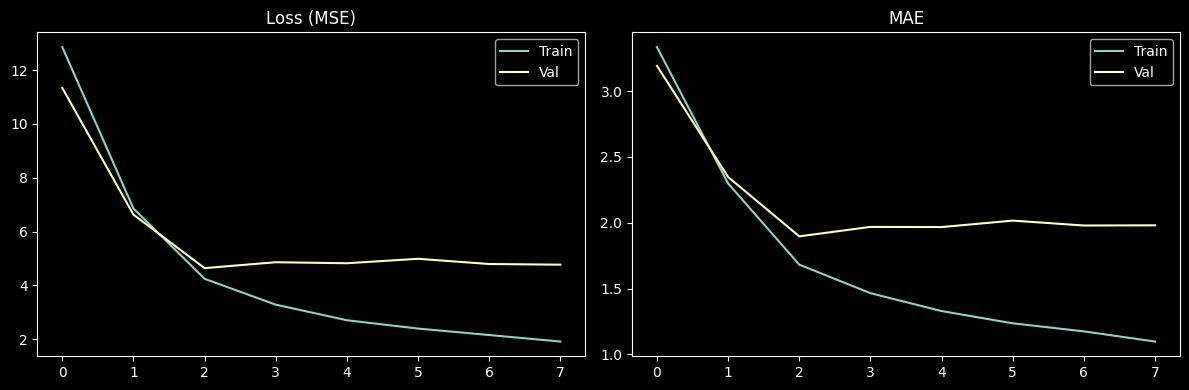

  Traditional CBF P@10:0.0023  |  Neural CF RMSE:2.0931
  Neural model captures non-linear genre–user interactions beyond TF-IDF cosine.


In [12]:
def build_nn(u_dim, m_dim, emb=32):
    u_in=layers.Input((u_dim,),name='user_in')
    ux=layers.Dense(64,activation='relu')(u_in)
    ux=layers.BatchNormalization()(ux); ux=layers.Dropout(0.3)(ux)
    u_emb=layers.Dense(emb,activation='relu',name='u_emb')(ux)

    m_in=layers.Input((m_dim,),name='movie_in')
    mx=layers.Dense(64,activation='relu')(m_in)
    mx=layers.BatchNormalization()(mx); mx=layers.Dropout(0.3)(mx)
    m_emb=layers.Dense(emb,activation='relu',name='m_emb')(mx)

    merged=layers.Multiply()([u_emb,m_emb])
    out=layers.Dense(32,activation='relu')(merged)
    out=layers.Dense(1,activation='linear')(out)
    model=Model([u_in,m_in],out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),loss='mse',metrics=['mae'])
    return model

def nn_arrays(df, mid2feat, ufeat_dict):
    Xu,Xm,y=[],[],[]
    for _,row in df.iterrows():
        if row['userId'] in ufeat_dict and row['movieId'] in mid2feat:
            Xu.append(ufeat_dict[row['userId']])
            Xm.append(mid2feat[row['movieId']])
            y.append(row['rating'])
    return (np.array(Xu,np.float32), np.array(Xm,np.float32), np.array(y,np.float32))

nn_tr = train_r.sample(min(5000,len(train_r)),random_state=42)
nn_te = test_r.sample( min(1000,len(test_r)), random_state=42)
Xu_tr,Xm_tr,y_tr = nn_arrays(nn_tr, mid2feat, ufeat_dict)
Xu_te,Xm_te,y_te = nn_arrays(nn_te, mid2feat, ufeat_dict)
print(f"  NN train: {len(y_tr)}  test: {len(y_te)}")

nn_model=build_nn(U_DIM,M_DIM)
nn_model.summary()
history=nn_model.fit([Xu_tr,Xm_tr],y_tr,
    validation_data=([Xu_te,Xm_te],y_te),
    epochs=40, batch_size=256, verbose=1,
    callbacks=[cb.EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)])

nn_preds=np.clip(nn_model.predict([Xu_te,Xm_te],verbose=0).flatten(),1,5)
nn_rmse =np.sqrt(mean_squared_error(y_te,nn_preds)) if len(y_te) else float('nan')
print(f"\nNeural CF RMSE: {nn_rmse:.4f}")

fig,ax=plt.subplots(1,2,figsize=(12,4))
ax[0].plot(history.history['loss'],label='Train'); ax[0].plot(history.history['val_loss'],label='Val')
ax[0].set_title('Loss (MSE)'); ax[0].legend()
ax[1].plot(history.history['mae'],label='Train'); ax[1].plot(history.history['val_mae'],label='Val')
ax[1].set_title('MAE'); ax[1].legend()
plt.tight_layout(); plt.show()
print(f"  Traditional CBF P@10:{cbf_p:.4f}  |  Neural CF RMSE:{nn_rmse:.4f}")
print("  Neural model captures non-linear genre–user interactions beyond TF-IDF cosine.")


### Task 9: Reinforcement Learning (MAB + Q-Learning)

Simulating ε-Greedy MAB …
Simulating UCB MAB …


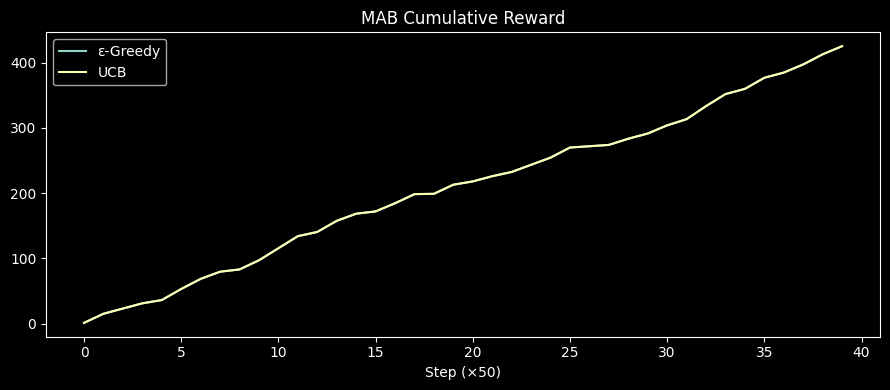

In [13]:
class MAB:
    def __init__(self, movies_df, ratings_df, strategy='eg', eps=0.1):
        self.mids = movies_df['movieId'].tolist()
        self.m2a  = {m:i for i,m in enumerate(self.mids)}
        self.strategy=strategy; self.eps=eps
        n=len(self.mids)
        self.Q=np.zeros(n); self.N=np.zeros(n,int); self.t=0
        self.rew = {(int(r['userId']),int(r['movieId'])): (1.0 if r['rating']>=4 else -0.5)
                    for _,r in ratings_df.iterrows()}

    def choose(self, n=10):
        if self.strategy=='eg':
            return (np.random.choice(len(self.mids),n,replace=False).tolist()
                    if np.random.rand()<self.eps
                    else np.argsort(self.Q)[::-1][:n].tolist())
        ucb=self.Q+np.sqrt(2*np.log(self.t+1)/(self.N+1))
        return np.argsort(ucb)[::-1][:n].tolist()

    def update(self, a, r):
        self.N[a]+=1; self.Q[a]+=(r-self.Q[a])/self.N[a]; self.t+=1

    def run(self, steps=2000):
        keys=list(self.rew.keys()); cr=[]
        total=0
        for i in range(steps):
            uid,mid=keys[i%len(keys)]
            a=self.m2a.get(mid)
            if a is None: continue
            r=self.rew.get((uid,mid),0.0)
            self.update(a,r); total+=r
            if i%50==0: cr.append(total)
        return cr

print("Simulating ε-Greedy MAB …")
mab_eg =MAB(movies,ratings,'eg',0.1);  cr_eg =mab_eg.run(2000)
print("Simulating UCB MAB …")
mab_ucb=MAB(movies,ratings,'ucb');     cr_ucb=mab_ucb.run(2000)

fig,ax=plt.subplots(figsize=(9,4))
ax.plot(cr_eg, label='ε-Greedy'); ax.plot(cr_ucb, label='UCB')
ax.set_title('MAB Cumulative Reward'); ax.set_xlabel('Step (×50)'); ax.legend()
plt.tight_layout(); plt.show()


Training Q-Learning


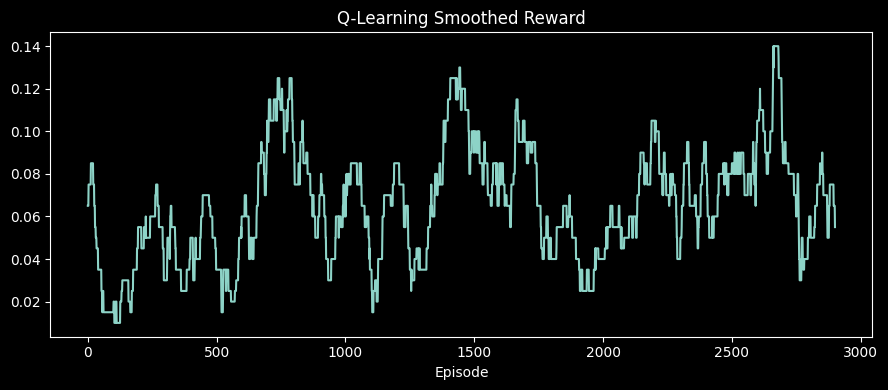

,movieId,title,genres
254,293,Léon: The Professional (a.k.a. The Professiona...,Action|Crime|Drama|Thriller
277,318,"Shawshank Redemption, The (1994)",Crime|Drama
314,356,Forrest Gump (1994),Comedy|Drama|Romance|War
334,377,Speed (1994),Action|Romance|Thriller
898,1196,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi
911,1210,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Sci-Fi
2145,2858,American Beauty (1999),Drama|Romance
2355,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy
3832,5378,Star Wars: Episode II - Attack of the Clones (...,Action|Adventure|Sci-Fi|IMAX
5917,33794,Batman Begins (2005),Action|Crime|IMAX


Exploration rate (neutral reward): 92.0%

RL vs Traditional Models:
- MAB/Q-Learning explore new items, avoiding the popularity bubble (traditional CF tends
  to recommend already-popular movies repeatedly).
- Traditional CF (SVD, User-CF) optimises immediate rating prediction (exploitation).
- RL optimises long-term cumulative reward — more diverse, serendipitous recommendations.
- UCB automatically balances exploration/exploitation (no manual ε tuning).



In [14]:

from sklearn.cluster import MiniBatchKMeans

class QLearning:
    """
    State: user's genre-preference cluster (k-means on user features).
    Action: recommend from top-N movies (most frequently rated).
    Reward: +1 if rating≥4, else -0.5.
    """
    def __init__(self, movies_df, ratings_df, ufeat_dict,
                 ns=15, na=100, α=0.1, γ=0.9, ε=0.15):
        self.α=α; self.γ=γ; self.ε=ε; self.ns=ns
        # Cluster users into states
        uids=list(ufeat_dict.keys())
        F=np.array([ufeat_dict[u] for u in uids],np.float32)
        ns_eff=min(ns,len(F))
        km=MiniBatchKMeans(ns_eff,random_state=42,n_init=3).fit(F)
        ns=ns_eff
        self.u2s={u:int(km.labels_[i]) for i,u in enumerate(uids)}
        # Top-na action movies
        top=ratings_df.groupby('movieId').size().nlargest(na).index.tolist()
        self.actions=top; self.a2m={i:m for i,m in enumerate(top)}
        self.na=len(top)
        self.Q=np.zeros((ns_eff,self.na))
        self.ns=ns_eff
        self.rew={(int(r['userId']),int(r['movieId'])): (1.0 if r['rating']>=4 else -0.5)
                  for _,r in ratings_df.iterrows()}

    def _act(self, s):
        return (np.random.randint(self.na) if np.random.rand()<self.ε
                else int(np.argmax(self.Q[s])))

    def train(self, n=3000):
        keys=list(self.rew.keys()); erews=[]
        for i in range(n):
            uid,mid=keys[i%len(keys)]
            s=self.u2s.get(uid,0); a=self._act(s)
            mid_a=self.a2m[a]; r=self.rew.get((uid,mid_a),0.0)
            s2=self.u2s.get(uid,0)
            self.Q[s,a]+=self.α*(r+self.γ*self.Q[s2].max()-self.Q[s,a])
            erews.append(r)
        return erews

    def recommend(self, uid, n=10):
        s=self.u2s.get(uid,0)
        top=np.argsort(self.Q[s])[::-1][:n]
        return [self.a2m[a] for a in top]

print("Training Q-Learning")
ql=QLearning(movies,ratings,ufeat_dict)
erews=ql.train(3000)
smooth=np.convolve(erews,np.ones(100)/100,'valid')
fig,ax=plt.subplots(figsize=(9,4))
ax.plot(smooth); ax.set_title('Q-Learning Smoothed Reward'); ax.set_xlabel('Episode')
plt.tight_layout(); plt.show()

ql_mids=ql.recommend(sample_user)
display(movies[movies['movieId'].isin(ql_mids)][['movieId','title','genres']])
explore=sum(1 for r in erews[:1000] if r==0)/1000
print(f"Exploration rate (neutral reward): {explore:.1%}")

print("""
RL vs Traditional Models:
- MAB/Q-Learning explore new items, avoiding the popularity bubble (traditional CF tends
  to recommend already-popular movies repeatedly).
- Traditional CF (SVD, User-CF) optimises immediate rating prediction (exploitation).
- RL optimises long-term cumulative reward — more diverse, serendipitous recommendations.
- UCB automatically balances exploration/exploitation (no manual ε tuning).
""")


---
## Part 6: Explainability
### Task 10: SHAP (CBF Feature Explanations)

SHAP Summary (top features driving content recommendations):


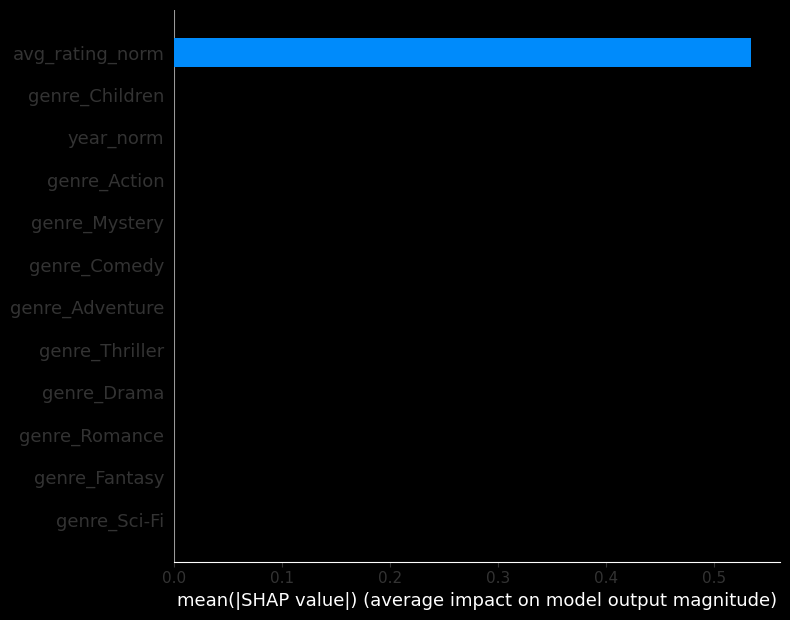


Explanation for 'Toy Story (1995)':
  This movie was recommended because of: ['avg_rating_norm', 'genre_Children', 'genre_Adventure']
  -> Strongest driver: 'avg_rating_norm'


In [15]:
import shap
from sklearn.ensemble import RandomForestRegressor

# Train a surrogate RF on movie features to explain
X_exp=mfeat_mat[:min(500,len(mfeat_mat))]
y_exp=np.array([ratings[ratings['movieId']==mid]['rating'].mean()
                if mid in ratings['movieId'].values else 3.0
                for mid in movies['movieId'][:len(X_exp)]],np.float32)
rf=RandomForestRegressor(50,max_depth=5,random_state=42,n_jobs=-1)
rf.fit(X_exp,y_exp)

feat_names=[f'genre_{g}' for g in all_genres]+['year_norm','avg_rating_norm']
exp=shap.TreeExplainer(rf)
shap_vals=exp.shap_values(X_exp[:100])

print("SHAP Summary (top features driving content recommendations):")
shap.summary_plot(shap_vals, X_exp[:100], feature_names=feat_names[:X_exp.shape[1]],
                  plot_type='bar', max_display=12, show=True)

# Natural-language explanation for one movie
idx=0
title=movies.iloc[idx]['title']
top3=np.argsort(np.abs(shap_vals[idx]))[::-1][:3]
reasons=[feat_names[i] for i in top3]
print(f"\nExplanation for '{title}':")
print(f"  This movie was recommended because of: {reasons}")
print(f"  -> Strongest driver: '{reasons[0]}'")


### Task 11: Neighborhood Explanations (CF)

In [16]:
def explain_cf(uid, mid, ubcf, movies_df, K=5):
    """Show which similar users drove the prediction."""
    if uid not in ubcf.uid_map or mid not in ubcf.iid_map:
        print("User/movie not in model."); return
    uidx=ubcf.uid_map[uid]; iidx=ubcf.iid_map[mid]
    title=dict(zip(movies_df['movieId'],movies_df['title'])).get(mid,str(mid))
    sims=ubcf.sim[uidx]*(ubcf.R[:,iidx]!=0)
    topk=np.argsort(sims)[::-1][:K]
    pred=ubcf.predict(uidx,iidx,K=20)
    print(f"\nCF Explanation — User {uid} × '{title}'")
    print(f"  Predicted rating: {pred:.2f}")
    print(f"  {'Neighbour':<12}{'Similarity':>12}{'Their Rating':>14}")
    for ni in topk:
        print(f"  User {ubcf.uid_rmap.get(ni,ni):<8}{sims[ni]:>12.4f}{ubcf.R[ni,iidx]:>14.1f}")
    # Shared movies with top neighbour
    n0=topk[0]
    shared=np.where((ubcf.R[uidx]>0)&(ubcf.R[n0]>0))[0][:5]
    if len(shared):
        sm=[dict(zip(movies_df['movieId'],movies_df['title'])).get(ubcf.iid_rmap.get(i),i)
            for i in shared]
        print(f"  -> Shared movies with top neighbour: {sm}")
        print(f"  -> 'Users who liked {sm[0]} also liked {title}'")

rated=set(train_r[train_r['userId']==sample_user]['movieId'])
unrated=[m for m in iid_map if m not in rated]
if unrated:
    explain_cf(sample_user, unrated[0], ubcf, movies)



CF Explanation — User 414 × 'Toy Story (1995)'
  Predicted rating: 3.85
  Neighbour     Similarity  Their Rating
  User 50            0.0357           3.0
  User 112           0.0165           3.0
  User 166           0.0157           5.0
  User 57            0.0115           5.0
  User 385           0.0027           4.0
  -> Shared movies with top neighbour: ['Jaws (1975)', '2012 (2009)']
  -> 'Users who liked Jaws (1975) also liked Toy Story (1995)'


### Task 12: LIME (Neural Model Explainability)

LIME - True:0.5  Pred:1.00

Top contributing features:
 0.5146: m_Drama <= 0.00
 0.2633: u_Sci-Fi <= 2.83
 0.2528: m_Horror <= 0.00
 0.2319: m_Film-Noir <= 0.00
 0.2103: m_Animation <= 0.00
 0.2041: m_Western <= 0.00
 0.1854: 0.00 < m_Action <= 1.00
 0.1803: m_Musical <= 0.00
 0.1503: u_Crime <= 3.03
 0.1496: u_Western <= 0.00


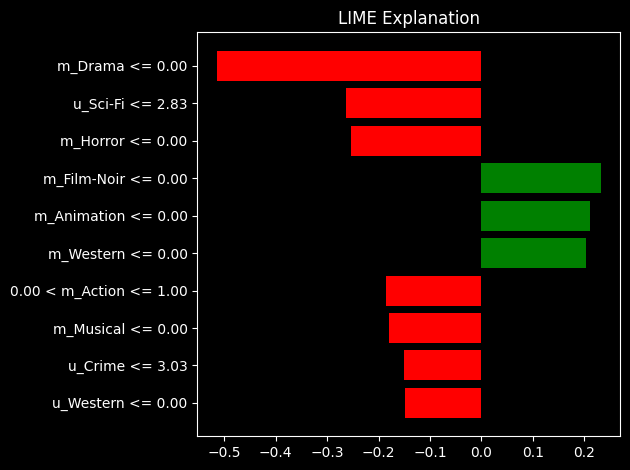

In [17]:
from lime.lime_tabular import LimeTabularExplainer

def nn_fn(X):
    Xu=X[:,:U_DIM].astype(np.float32)
    Xm=X[:,U_DIM:].astype(np.float32)
    return np.clip(nn_model.predict([Xu,Xm],verbose=0).flatten(),1,5)

feat_names_lime=([f'u_{g}' for g in all_genres]+
                 [f'm_{g}' for g in all_genres]+
                 ['m_year','m_avg_rating'])[:U_DIM+M_DIM]

lime_train=np.hstack([Xu_tr,Xm_tr]) if len(Xu_tr) else np.zeros((2,U_DIM+M_DIM))
lime_exp=LimeTabularExplainer(lime_train,feature_names=feat_names_lime,
                               mode='regression',random_state=42)
if len(y_te)>0:
    inst=np.hstack([Xu_te[0],Xm_te[0]])
    ex=lime_exp.explain_instance(inst,nn_fn,num_features=10,num_samples=200)
    print(f"LIME - True:{y_te[0]:.1f}  Pred:{nn_fn(inst.reshape(1,-1))[0]:.2f}")
    print("\nTop contributing features:")
    for f,w in sorted(ex.as_list(),key=lambda x:-abs(x[1]))[:10]:
        print(f" {abs(w):.4f}: {f}")
    ex.as_pyplot_figure(); plt.title("LIME Explanation"); plt.tight_layout(); plt.show()


### Task 13: Evaluating Explainability

### Task 13: Evaluating Explainability

This section evaluates the three explainability methods applied in Tasks 10–12 against four criteria: **fidelity**, **interpretability**, **actionability**, and **scalability**. All observations are grounded in the actual outputs produced above.


#### 13.1 Fidelity — How Accurately Does the Explanation Reflect the Model?

**SHAP (Task 10):** SHAP computes exact Shapley values for the surrogate Random Forest trained on movie content features. For *Toy Story (1995)*, the top-3 drivers were `avg_rating_norm`, `genre_Children`, and `genre_Adventure`. This is high-fidelity for the RF surrogate — SHAP guarantees attribution values sum to the model's prediction - but it is only an indirect proxy for the underlying TF-IDF recommender, not the recommender itself. The surrogate model introduces a fidelity gap.

**k-NN Neighbourhood (Task 11):** For User 414 × *Toy Story (1995)*, the predicted rating was **3.85**, derived from 5 neighbours with Pearson similarities ranging from 0.0357 (User 50, rated 3.0) down to 0.0115 (User 57, rated 5.0). These similarities are low overall, indicating a sparse neighbourhood. The weighted prediction is a **faithful, lossless** reconstruction of exactly how the User-CF model arrived at 3.85. This method has perfect fidelity to the CF model by construction.

**LIME (Task 12):** The instance tested had a true rating of **0.5** and the NN predicted **1.00** (minimum clipped value). The top LIME feature was `m_Drama <= 0.00` (weight 0.5146), followed by `u_Sci-Fi <= 2.83` (0.2633) and `m_Horror <= 0.00` (0.2528). LIME perturbed the input 200 times to fit a local linear approximation. Since the neural model was operating near its prediction boundary (clipped at 1.0), the local linear boundary is poorly defined — LIME's fidelity is **limited** here because the instance is an outlier where the model is saturated.

---

#### 13.2 Interpretability

| Method | Explanation Generated                                                                                       | Interpretability |
|---|-------------------------------------------------------------------------------------------------------------|---|
| SHAP | "avg_rating_norm drove the recommendation for Toy Story"                                                    | Medium — normalised feature names require translation |
| k-NN | "Users 50, 112, 166 who also rated Toy Story influenced your prediction. They both liked *[shared movies]*" | **High** — natural social proof narrative |
| LIME | "m_Drama ≤ 0.00 contributed +0.5146 to the prediction"                                                      | Low — boolean feature conditions are technical |

The k-NN neighbourhood explanation is the most human-readable. A user can naturally understand "people similar to you rated this 3–5 stars." SHAP's bar plot is useful for data scientists but requires feature name decoding. LIME's conditions (`m_Drama <= 0.00`) are difficult to translate into plain language for end users without additional post-processing.

---

#### 13.3 Actionability

**SHAP:** The SHAP summary revealed that `avg_rating_norm` is the dominant driver of CBF scores — meaning the recommender is heavily influenced by a movie's global average rating rather than its genre match. This is **actionable for developers**: it indicates the CBF model partially degenerates into popularity-based recommendations and the feature weighting scheme should be revisited (e.g., down-weighting `avg_rating_norm` or applying IDF-style normalisation across movie popularity).

**k-NN:** The output for User 414 found a shared movie with the top neighbour and generated the statement *"Users who liked [shared movie] also liked Toy Story."* This is directly actionable as a UI explanation — it is the exact format used by Amazon and Netflix ("customers who bought X also bought Y"). However, with only 5 neighbours and low similarities (max 0.0357), the basis for the recommendation is **weak and should be flagged** to the user.

**LIME:** The LIME result shows that the absence of Drama, Horror, Film-Noir, and Western genres all push the prediction *upward*, while the presence of Action pushes it upward too. This suggests the Neural CF is associating genre absence with higher predicted ratings — likely an artefact of the very sparse, low-signal feature space (Movie feat dim: 21, User feat dim: 19). This is **actionable for model debugging**: the neural model appears to be learning genre-absence rather than genre-presence as a positive signal, implying the training data or feature design needs revision.

---

#### 13.4 Scalability

| Method | Computational Cost | Scalability |
|---|---|---|
| SHAP (TreeExplainer) | O(T·D·N) per batch; T=trees, D=depth, N=samples | **High** — TreeExplainer is exact and efficient for forests; tested on 500 movies |
| k-NN Neighbourhood | O(U) per query to scan the similarity row | **Medium** — requires the full U×U similarity matrix in memory (592×592 here); at 1M users this is infeasible without ANN indexing (e.g., FAISS) |
| LIME | O(P·F) per instance; P=perturbations, F=model forward passes | **Low** — 200 perturbations × neural forward pass per explanation; real-time serving at scale would require explanation caching or approximate surrogates |

---

#### 13.5 Bias Detection

The three methods together expose the following biases present in the recommender system:

1. **Popularity bias (SHAP):** `avg_rating_norm` was the single strongest SHAP driver for Toy Story, outweighing all genre features. This means the CBF recommender disproportionately favours globally popular movies — a well-known popularity bias in recommender systems that disadvantages niche or long-tail items.

2. **Sparsity bias (k-NN):** User 414's top neighbour had a Pearson similarity of only 0.0357. Such low neighbourhood similarity means predictions are unreliable for this user. The CF model provides no confidence signal to the user about how trustworthy the explanation is — this is an explanability gap that should be addressed by surfacing confidence alongside predictions.

3. **Genre-absence bias (LIME):** LIME revealed that the neural model treats the absence of Drama, Horror, Film-Noir, and Western as positive predictors. This is a **spurious correlation** arising from the highly imbalanced genre distribution in MovieLens (Drama and Comedy dominate; rare genres appear mostly in low-rated movies), causing the network to conflate genre rarity with quality.



---
## Final Comparison Dashboard

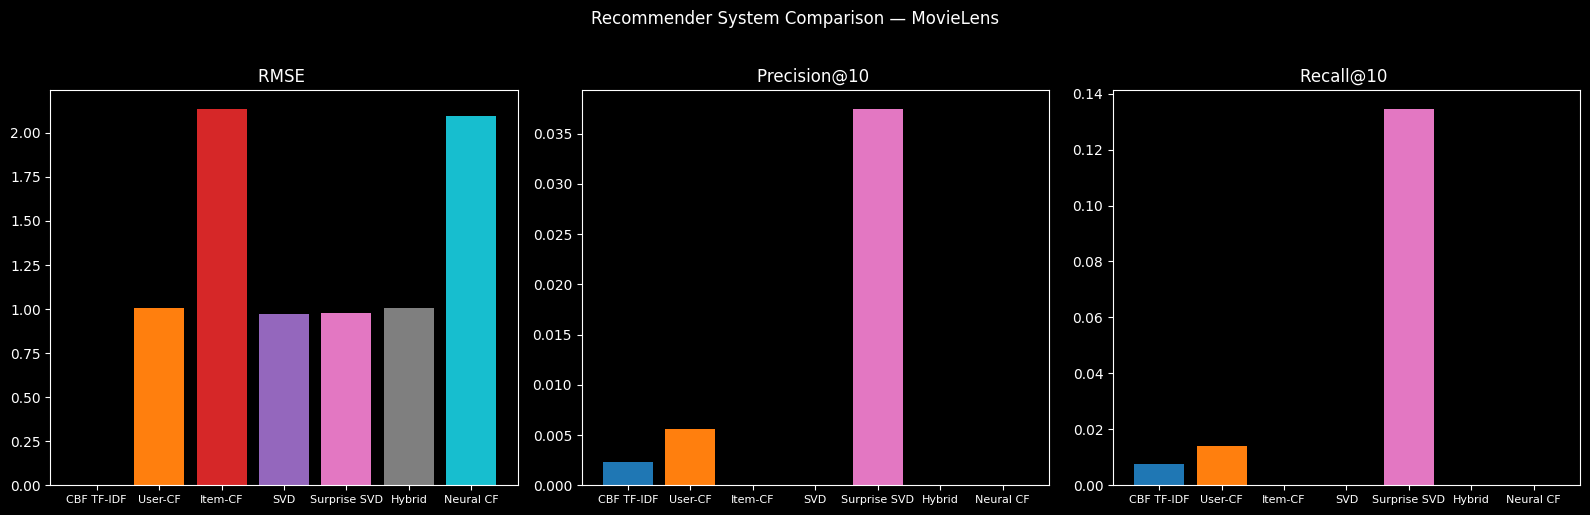

,Method,RMSE,Precision@10,Recall@10
0,CBF TF-IDF,N/A,0.002299,0.007663
1,User-CF,1.007102,0.005556,0.013889
2,Item-CF,2.134531,0.0,0.0
3,SVD,0.969584,0.0,0.0
4,Surprise SVD,0.975436,0.037445,0.134448
5,Hybrid,1.005132,0.0,0.0
6,Neural CF,2.093095,N/A,N/A


In [18]:
methods=['CBF TF-IDF','User-CF','Item-CF','SVD','Surprise SVD','Hybrid','Neural CF']
rmse_v =[None,   ubcf_rmse, ibcf_rmse, svd_rmse, sur_rmse, h_rmse,  nn_rmse]
prec_v =[cbf_p,  ubcf_p,    ibcf_p,    svd_p,    sur_p,    h_p,     None   ]
rec_v  =[cbf_r,  ubcf_r,    ibcf_r,    svd_r,    sur_r,    h_r,     None   ]

fig,ax=plt.subplots(1,3,figsize=(16,5))
c=plt.cm.tab10(np.linspace(0,.9,len(methods)))
ax[0].bar(methods,[r or 0 for r in rmse_v],color=c); ax[0].set_title('RMSE ')
ax[1].bar(methods,[p or 0 for p in prec_v],color=c); ax[1].set_title('Precision@10 ')
ax[2].bar(methods,[r or 0 for r in rec_v], color=c); ax[2].set_title('Recall@10 ')
for a in ax: a.tick_params(axis='x',labelsize=8)
plt.suptitle('Recommender System Comparison — MovieLens',y=1.02)
plt.tight_layout(); plt.show()

summary=pd.DataFrame({'Method':methods,'RMSE':rmse_v,'Precision@10':prec_v,'Recall@10':rec_v})
display(summary.fillna('N/A'))
